In [1]:
# ─────────────────────────────────────────────────────
# IMPORTS grouped by purpose:
#   DATA        → pandas, numpy
#   MODELS      → the three baseline classifiers
#   METRICS     → every metric in our priority list
#   PLOTTING    → confusion matrix heatmap, ROC curve
# ─────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.neighbors      import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,      # MCC / Phi coefficient
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All imports loaded')

✅ All imports loaded


In [3]:
# ─────────────────────────────────────────────────────
# WHY repeat preprocessing instead of loading the CSV?
#
# The saved CSV is PRE-SCALE (human-readable units).
# We need the SCALED arrays for KNN and Logistic Regression.
# Re-running the pipeline from cleaned CSV takes < 1 second
# and guarantees we use the exact same scaler fit.
#
# In a production pipeline you would load X_train_scaled
# from a pickle; here we keep it explicit for learning.
# ─────────────────────────────────────────────────────

# Load the cleaned (imputed + capped + engineered) CSV
df = pd.read_csv('../data/processed/diabetes_clean.csv')

X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Stratified split — same seed as Notebook 02
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale — fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'Target balance — Train: {y_train.mean()*100:.1f}% diabetic | Test: {y_test.mean()*100:.1f}% diabetic')

Train: (614, 11) | Test: (154, 11)
Target balance — Train: 34.9% diabetic | Test: 35.1% diabetic


In [4]:
# ─────────────────────────────────────────────────────
# This function is reused for EVERY model in this notebook
# and in Notebook 04. It computes all 5 priority metrics
# and returns them as a dictionary.
#
# WHY average='binary'?
#   Our target has exactly 2 classes (0 and 1).
#   'binary' computes precision/recall/f1 for the POSITIVE
#   class (1 = diabetic), which is exactly what we care about.
#
# WHY pos_label=1?
#   Explicit is better than implicit. We declare that
#   "1" is the positive class (diabetic) so sklearn knows
#   which class's recall we want maximised.
# ─────────────────────────────────────────────────────

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Compute all priority metrics and return as a dict.
    
    Parameters:
        model_name : str  – label for the results table
        y_true     : array – ground truth labels
        y_pred     : array – predicted labels (0 or 1)
        y_prob     : array – predicted probabilities for class 1
    
    Returns:
        dict with all metrics
    """
    return {
        'Model'    : model_name,
        'Recall'   : recall_score(y_true, y_pred, pos_label=1),
        'F1-Score' : f1_score(y_true, y_pred, pos_label=1),
        'MCC (Phi)': matthews_corrcoef(y_true, y_pred),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=1)
    }

# Storage list — we append each model's results here
all_results = []

print('✅ Evaluation function ready')

✅ Evaluation function ready


In [5]:
# ─────────────────────────────────────────────────────
# LOGISTIC REGRESSION — the simplest meaningful classifier
#
# What it does:
#   Fits a linear decision boundary: w1*x1 + w2*x2 + ... + b = 0
#   Then passes the result through a sigmoid → probability in [0,1]
#   If probability ≥ 0.5 → predict 1 (diabetic)
#
# Why it's a good baseline:
#   • Fastest to train
#   • Outputs calibrated probabilities (needed for ROC-AUC)
#   • If this model already scores well, the data has strong
#     linear signal → simpler models may suffice
#
# Hyperparameters explained:
#   max_iter=1000  → maximum optimisation iterations;
#                    100 (default) sometimes isn't enough
#                    for scaled multi-feature data
#   random_state=42 → reproducibility
#   C=1.0 (default) → inverse regularisation strength;
#                      1.0 is neutral, we test more in Notebook 04
# ─────────────────────────────────────────────────────

lr = LogisticRegression(max_iter=1000, random_state=42)

# Train
lr.fit(X_train_scaled, y_train)

# Predict labels AND probabilities
lr_pred = lr.predict(X_train_scaled if False else X_test_scaled)  # test set
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

# Evaluate
lr_results = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)
all_results.append(lr_results)

# Print classification report (detailed per-class breakdown)
print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, lr_pred, target_names=['Non-Diabetic', 'Diabetic']))

print(f"Recall:    {lr_results['Recall']:.4f}")
print(f"F1-Score:  {lr_results['F1-Score']:.4f}")
print(f"MCC (Phi): {lr_results['MCC (Phi)']:.4f}")
print(f"ROC-AUC:   {lr_results['ROC-AUC']:.4f}")
print(f"Accuracy:  {lr_results['Accuracy']:.4f}")

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.82      0.79       100
    Diabetic       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

Recall:    0.5185
F1-Score:  0.5600
MCC (Phi): 0.3529
ROC-AUC:   0.8085
Accuracy:  0.7143


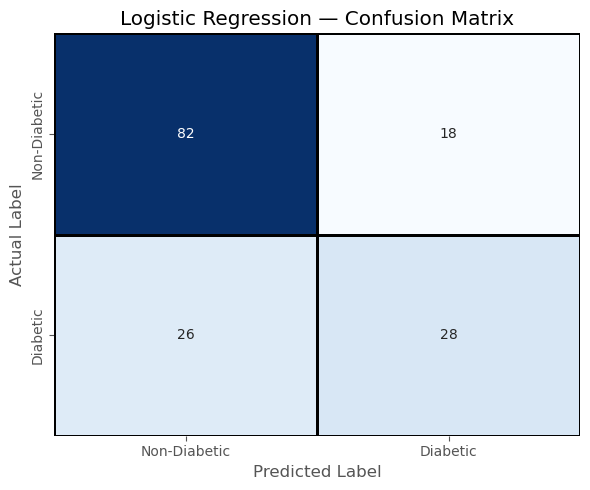

  True Negatives  (TN): 82
  False Positives (FP): 18
  False Negatives (FN): 26  ← diabetic patients MISSED
  True Positives  (TP): 28


In [6]:
# ─────────────────────────────────────────────────────
# CONFUSION MATRIX for Logistic Regression
#
# Layout:
#                  Predicted
#                No      Yes
#   Actual No  [ TN      FP ]
#   Actual Yes [ FN      TP ]
#
# In medical screening:
#   FN (False Negative) = diabetic patient missed → DANGEROUS
#   FP (False Positive) = healthy patient flagged → causes anxiety but not lethal
#
# So we want FN to be as LOW as possible (= high Recall).
# ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=ax, linewidths=1, linecolor='black',
            cbar=False)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Logistic Regression — Confusion Matrix')

plt.tight_layout()
plt.show()

print(f"  True Negatives  (TN): {cm[0][0]}")
print(f"  False Positives (FP): {cm[0][1]}")
print(f"  False Negatives (FN): {cm[1][0]}  ← diabetic patients MISSED")
print(f"  True Positives  (TP): {cm[1][1]}")